In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# We define the returns matrix for our portfolio
mu = np.array([0.08, 0.12, 0.05])

# We define the covariance matrix for the 3 assets inside the portfolio
sigma = np.array([
    [0.040, 0.012, 0.004],
    [0.012, 0.090, 0.006],
    [0.004, 0.006, 0.025]
])

In [4]:
# Define the number of assets and porftolios that will be created
n_assets = 3
n_portfolios = 50000

rng = np.random.default_rng(42)

# We use dirichlet as it allows us to comply with the two restrictions for our portfolio (No short selling as it only selects value from 0 to 1 and the sum of any vector extracted from it is equal to 1.)
n_pf_weights = rng.dirichlet(np.ones(n_assets), n_portfolios)

In [5]:
# Create the functions to calculate the expected return, variance and volatility of the portfolios
def portfolio_returns(weights, mu):
    return weights @ mu

def portfolio_variance(weights, cov):
    if weights.ndim == 1:
        return weights.T @ cov @ weights
    else:
        return ((weights@ cov) * weights).sum(axis=1)

def portfolio_volatility(weights, cov):
    return np.sqrt(portfolio_variance(weights, cov))

In [6]:
# Compute the expected returns, variance and volatilities of the 50,000 simulated portfolios
returns = portfolio_returns(n_pf_weights, mu)
variances = portfolio_variance(n_pf_weights, sigma)
volatilities = portfolio_volatility(n_pf_weights, sigma)

# Identify the index for the minimum variance portfolio and maximum return portfolios
mvp = np.argmin(variances)
mrp = np.argmax(returns)

To plot the portfolios in a two-dimensional space, we recall the rule $w_3 = 1 - w_1 - w_2$.

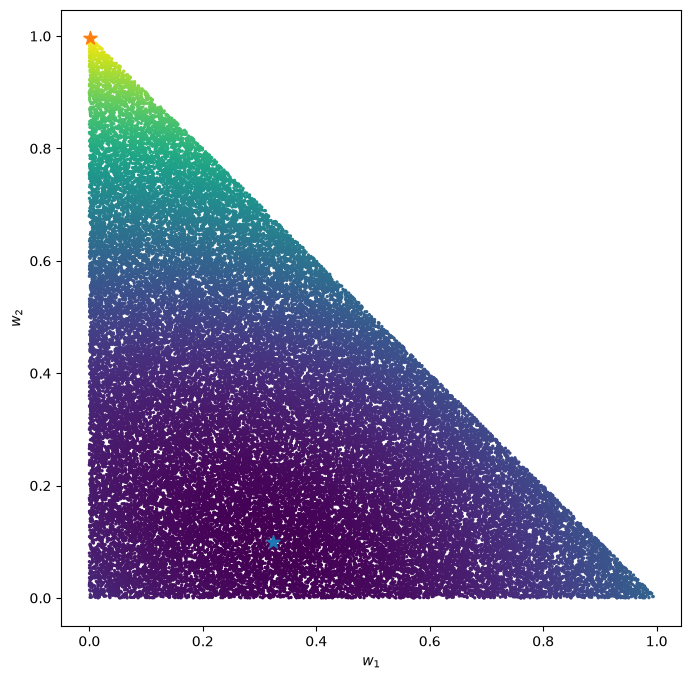

In [7]:
# Graph portfolios distributed by weights (w_1, w_2)

# 1. Determine w_1 and w_2 for all portfolios
w_1 = n_pf_weights[:,0]
w_2 = n_pf_weights[:,1]

fig, ax = plt.subplots(figsize=(8, 8))

# 2. Plot the portfolios
ax.scatter(x=w_1, y=w_2, c=variances, s=2)
ax.set_xlabel(r'$w_1$')
ax.set_ylabel(r'$w_2$')

# 3. Plot the Minimum Variance and Maximum Return Portfolio 
ax.scatter(n_pf_weights[mvp][0], n_pf_weights[mvp][1], s=100 , marker='*', label="Minimum Variance Portfolio")
ax.scatter(n_pf_weights[mrp][0], n_pf_weights[mrp][1], s=100, marker='*', label="Maximum Return Portfolio")
plt.show()

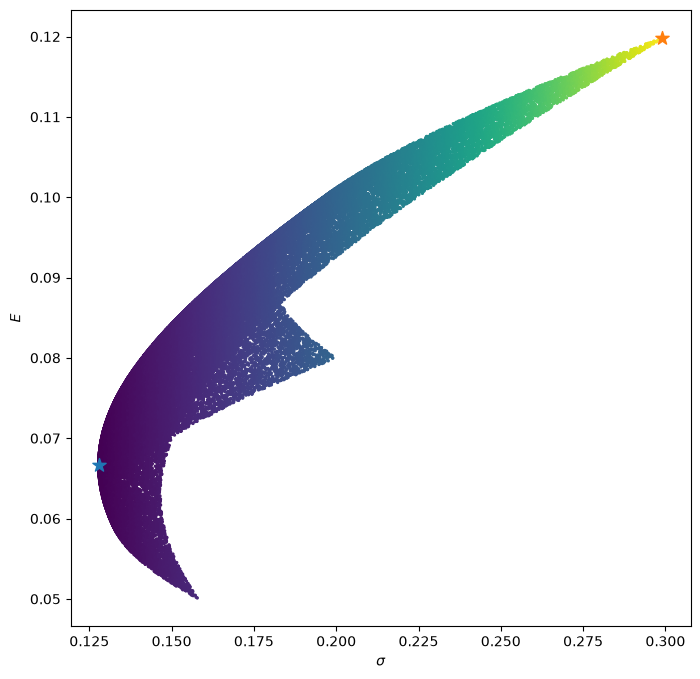

In [8]:
# Graph the porfolios in relation to their expected return (E) and variance(σ)
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(volatilities, returns, c=variances, s=2)
ax.set_xlabel(r'$σ$')
ax.set_ylabel(r'$E$')

# Plot the Minimum Variance and Maximum Return Portfolio 
ax.scatter(volatilities[mvp], returns[mvp], s=100 , marker='*', label="Minimum Variance Portfolio")
ax.scatter(volatilities[mrp], returns[mrp], s=100, marker='*', label="Maximum Return Portfolio")

**Efficient Frontier Approximation**

The efficient frontier plots portfolios ranging from the Minimum Variance Portfolio upwards and it can be identified as the line of portfolios formed along the upper part of the scatter plot, starting from the Minimum Variance Portfolio.

**Dominated Region**

The dominated region is the area of ​​the graph located below and to the right of the efficient frontier, as any portfolio in this zone is "dominated" by another portfolio on the efficient frontier that offers better conditions, either a greater return for the same risk or less risk for the same return.

**Why is minimizing variance within the simplex different from simply choosing the individual asset with the lowest volatility?**

The vertices of the simplex represent portfolios where 100% of the weight is allocated to just one of the three assets. The space between these three vertices represents an infinite range of possible portfolio combinations. 

The portfolio variance not only depends on individual asset variances but also on the covariances between assets. Because the assets are not perfectly correlated, combining them can reduce total portfolio variance. Therefore, the minimum-variance portfolio may lie inside the simplex and have lower variance than the least volatile individual asset.

# 2. **Global Minimum Variance Portfolio**

In [9]:
def global_minimum_variance(cov):
    J = np.ones(cov.shape[0])
    inv_cov = np.linalg.inv(cov)
    return (inv_cov @ J) / (J.T @ inv_cov @ J)

In [10]:
gmv_portfolio = global_minimum_variance(sigma)

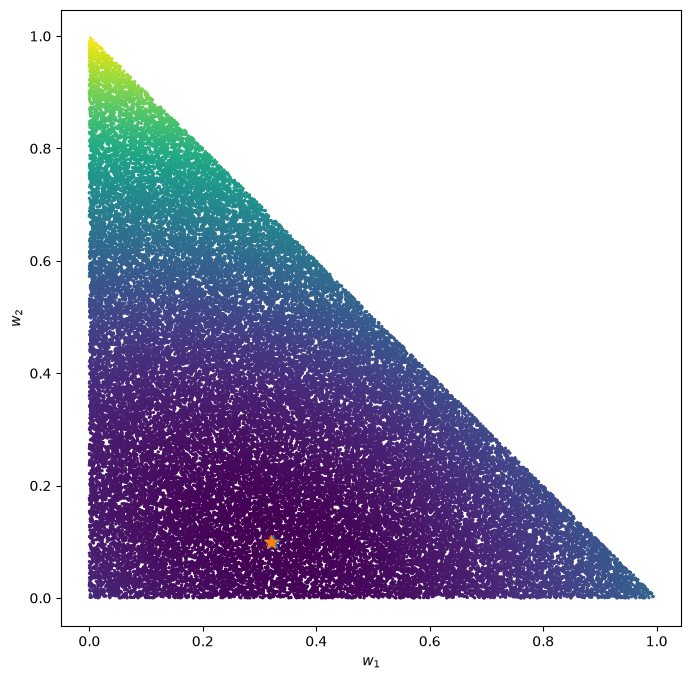

In [11]:
# Graph portfolios distributed by weights (w_1, w_2)

# 1. Determine w_1 and w_2 for all portfolios
w_1 = n_pf_weights[:,0]
w_2 = n_pf_weights[:,1]

fig, ax = plt.subplots(figsize=(8, 8))

# 2. Plot the portfolios
ax.scatter(x=w_1, y=w_2, c=variances, s=2)
ax.set_xlabel(r'$w_1$')
ax.set_ylabel(r'$w_2$')

# 3. Plot the Minimum Variance Portfolio approximation and the Global Minimum Variance Portfolio 
ax.scatter(n_pf_weights[mvp][0], n_pf_weights[mvp][1], s=100 , marker='*', label="Minimum Variance Portfolio")
ax.scatter(gmv_portfolio[0], gmv_portfolio[1], s=100, marker='*', label="Global Minimum Variance Portfolio ")
plt.show()

In [12]:
print (f'GMV Portfolio Weights:{gmv_portfolio}')
print (f'GMV Portfolio weighst approximation from 50,000 randomly generated portfolios: {n_pf_weights[mvp]}')

GMV Portfolio Weights:[0.32088681 0.10035006 0.57876313]
GMV Portfolio weighst approximation from 50,000 randomly generated portfolios: [0.32293156 0.09945521 0.57761323]


In [13]:
gmv_portfolio_variance = gmv_portfolio.T @ sigma @ gmv_portfolio
gmv_portfolio_vol = np.sqrt(gmv_portfolio_variance)
gmv_portfolio_return = gmv_portfolio @ mu

## **Efficient portfolio and Efficient Frontier**

In [14]:
def efficient_portfolio(mu, cov, target_return):
    #1. Create the vectors
    J = np.ones(cov.shape[0])
    A = np.column_stack((J, mu))
    b = np.array([1, target_return])

    # 2. Compute \Sigma{^-1} @ A
    cov_inv_A = np.linalg.solve(cov, A)

    #3. Compute the central block
    central_block = A.T @ cov_inv_A

    # 4. Compute gamma
    gamma = np.linalg.solve(central_block, b)

    #5. Compute the portfolio weights
    return cov_inv_A @ gamma


In [15]:
def efficient_frontier(mu, cov, n_points=100):

    # Given that the efficient frontier extends upwards from the Global Minimum Variance portfolio, we will take this as our starting point.
    gmv_weights = global_minimum_variance(cov)

    # Compute the minimum and maximum return from the assets
    start_point = gmv_weights @ mu
    end_point = np.max(mu)
    target_returns = np.linspace(start_point, end_point, n_points)

    # Save the results
    portfolio_risks = []
    portfolio_returns =[]
    portfolio_weights = []

    # Iterate on every portfolio
    for target in target_returns:
        w = efficient_portfolio(mu, cov, target)

        variance = w.T @ cov @ w
        risk = np.sqrt(variance)
        returns = w @ mu

        # Save the results
        portfolio_risks.append(risk)
        portfolio_returns.append(returns)
        portfolio_weights.append(w)

    # Finally, we return an array for each result list
    return np.array(portfolio_risks), np.array(portfolio_returns), np.array(portfolio_weights)

In [16]:
EF = efficient_frontier(mu, sigma, n_points=100)
EF_volatility, EF_returns, EF_weights = EF

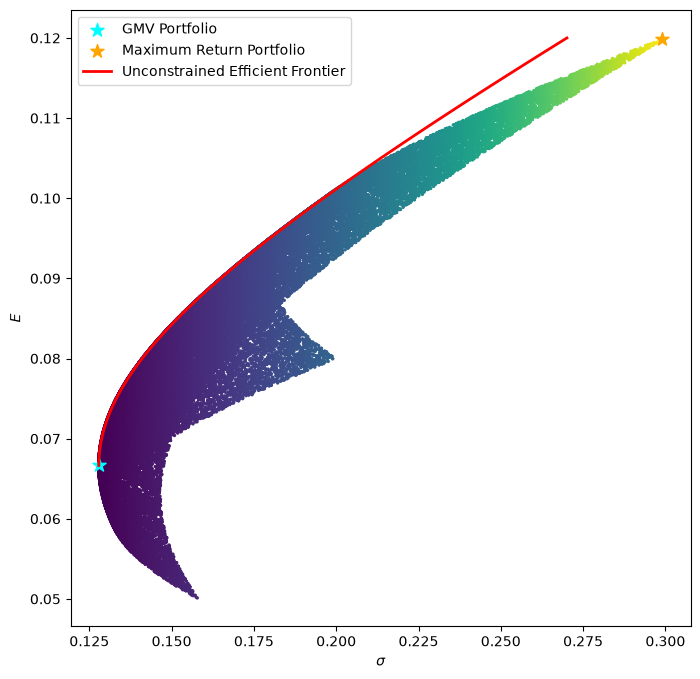

In [17]:
fig, ax = plt.subplots(figsize = (8,8))

# Plot the  50,000 portfolios
ax.scatter(volatilities, returns, s=2, c=variances)

# Plot the GMV and the MRP portfolio
ax.scatter(gmv_portfolio_vol, gmv_portfolio_return, s=100, marker="*", c="cyan", label="GMV Portfolio")
ax.scatter(volatilities[mrp], returns[mrp], s=100, marker='*',c="orange", label="Maximum Return Portfolio")

# Plot the Efficient Frontier
ax.plot(EF_volatility, EF_returns, linewidth=2, c="red", label="Unconstrained Efficient Frontier")

ax.set_xlabel(r"$\sigma$")
ax.set_ylabel(r"$E$")
ax.legend()
plt.show()